# Image Reconstruction
This notebook is a basic example of how to use Google Nano Banana to convert old photos into new looking ones in Jupyter Notebook/Python.

Let's import the necessary libraries:

In [10]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

load_dotenv("../../../_starter/.env")

True

### Start by setting up a client

In [11]:
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

# Reference image
To make edits to an image we will need to load an example that we can use as context.

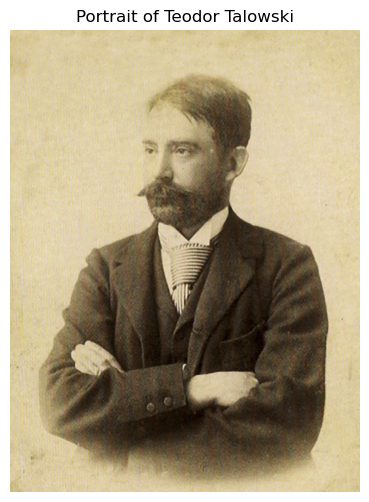

In [12]:
# Load the image
image_path = "../../assets/portrait_teodor_talowski.png"
image = Image.open(image_path)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title("Portrait of Teodor Talowski")
plt.show()

## Reconstruct the image
We can now use Gemini 2.5 flash image preview to rerender that image as if it was taken using modern camera.

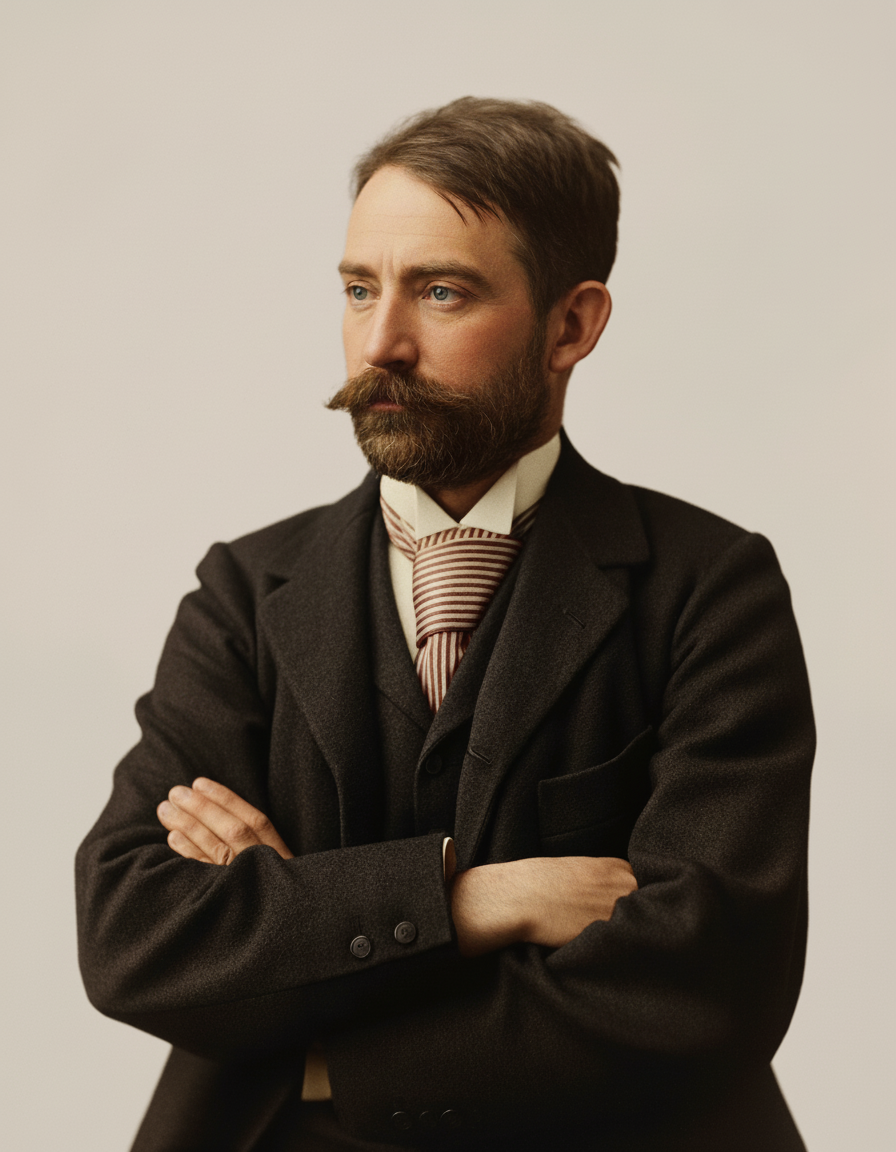

In [16]:
prompt = (
    "Reconstruct the image to make it look like a portrait taken a modern medium format camera like Phase One."
    "The image should be in AdobeRGB colour space."
    "Remove all defects such as scratches, dust, etc."
    "Fill in faded out parts of the image with the same texture as the rest of the image."
    "Make sure the color profile of the camera is set to Vivid and not part of the image is in sepia or black and white."
)

# Load the image as a reference
image_reference = image

response = client.models.generate_content(
    model="gemini-2.5-flash-image-preview",
    contents=[prompt, image_reference],
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("../../assets/portrait_teodor_talowski_reconstructed.png")

image

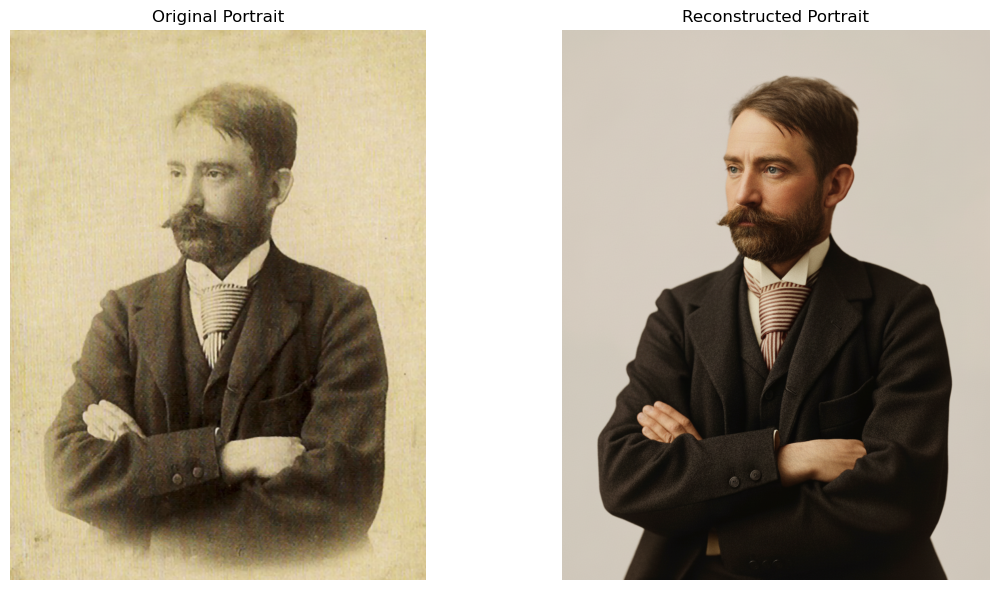

In [17]:
def show_images_side_by_side(image_paths, titles=None, figsize=(12, 6)):
    """
    Display multiple images side by side
    
    Args:
        image_paths: List of image file paths
        titles: List of titles for each image (optional)
        figsize: Figure size as tuple (width, height)
    """
    n_images = len(image_paths)
    
    # Create subplot grid
    fig, axes = plt.subplots(1, n_images, figsize=figsize)
    
    # Handle single image case
    if n_images == 1:
        axes = [axes]
    
    for i, (img_path, ax) in enumerate(zip(image_paths, axes)):
        # Load and display image
        img = Image.open("../../assets/"+img_path)
        ax.imshow(img)
        ax.axis('off')
        
        # Add title if provided
        if titles and i < len(titles):
            ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

# Example usage
image_paths = ['portrait_teodor_talowski.png', 'portrait_teodor_talowski_reconstructed.png']
titles = ['Original Portrait', 'Reconstructed Portrait']

show_images_side_by_side(image_paths, titles)